# Clear Sky Detection Demo With McClear
# 基于 McClear 的晴空检测演示

This notebook demonstrates the McClear-based workflow in the `bsrn` package, including data reading, clear-sky modeling, quality control tests, Reno clear-sky detection, and CSD-point visualization.
本笔记本演示 `bsrn` 包中基于 McClear 的工作流程，包括数据读取、晴空建模、质量控制测试、Reno 晴空检测与 CSD 点可视化。

## 1. Import libraries / 导入库

In [2]:
import os
import random
import pandas as pd
import bsrn

# Config: input file (same pattern as cloud_enhancement_events_detection.ipynb)
INPUT_FILE = "../../data/QIQ/qiq0924.dat.gz"

# Set display options
pd.options.display.max_columns = None
%matplotlib inline


## 2. Load QIQ September data / 加载 QIQ 9 月数据

In [3]:
# Extract station code from filename (e.g. qiq0924.dat.gz -> QIQ)
stn = os.path.basename(INPUT_FILE).split(".")[0][:3].upper()

if os.path.exists(INPUT_FILE):
    df = bsrn.io.readers.read_station_to_archive(INPUT_FILE, logical_records="lr0100")
    print(f"Data for {stn} loaded successfully (September 2024).")
    display(df.head())
else:
    raise FileNotFoundError(f"File not found: {INPUT_FILE}. Current working directory: {os.getcwd()}")


Data for QIQ loaded successfully (September 2024).


,ghi,bni,dhi,lwd,temp,rh,pressure
time,,,,,,,
2024-09-01 00:00:00+00:00,142.0,0.0,143.0,371.0,22.1,48.0,988.0
2024-09-01 00:01:00+00:00,141.0,0.0,141.0,371.0,22.2,49.0,988.0
2024-09-01 00:02:00+00:00,139.0,0.0,140.0,371.0,22.2,46.0,988.0
2024-09-01 00:03:00+00:00,139.0,0.0,139.0,371.0,22.2,45.0,988.0
2024-09-01 00:04:00+00:00,137.0,0.0,138.0,371.0,22.1,48.0,988.0


## 3. Clear-sky modeling with McClear / 使用 McClear 进行晴空建模

In [ ]:
# TODO: replace with your real SoDa / McClear email
# 请替换为您自己的 SoDa / McClear 邮箱
mcclear_email = "your_email@example.com"

df_cs = bsrn.modeling.clear_sky.add_clearsky_columns(
    df.copy(),
    station_code=stn,
    model="mcclear",
    mcclear_email=mcclear_email,
)

display(df_cs[["ghi", "ghi_clear", "bni", "bni_clear", "dhi", "dhi_clear"]].head())


,ghi,ghi_clear,bni,bni_clear,dhi,dhi_clear
time,,,,,,
2024-09-01 00:00:00+00:00,142.0,446.412,0.0,687.102,143.0,114.546
2024-09-01 00:01:00+00:00,141.0,449.172,0.0,688.938,141.0,114.780
2024-09-01 00:02:00+00:00,139.0,451.926,0.0,690.756,140.0,115.008
2024-09-01 00:03:00+00:00,139.0,454.668,0.0,692.556,139.0,115.236
2024-09-01 00:04:00+00:00,137.0,457.410,0.0,694.344,138.0,115.464


## 4. Run QC wrapper / 运行 QC 包装函数

`run_qc` runs a suite of BSRN quality control tests and adds flag columns (0 = pass, 1 = fail). By default it runs all six test groups:

<div style="text-align: left">

| Test | Level | Description | Flag columns |
|:-----|:------|:-------------|:-------------|
| **ppl** | 1 | Physically Possible Limits — absolute bounds for GHI, BNI, DHI, LWD | flagPPLGHI, flagPPLBNI, flagPPLDHI, flagPPLLWD |
| **erl** | 2 | Extremely Rare Limits — climatological limits for GHI, BNI, DHI, LWD | flagERLGHI, flagERLBNI, flagERLDHI, flagERLLWD |
| **closure** | 3 | Closure — $G_h$ vs $B_n \cos Z + D_h$ at low/high zenith | flag3lowSZA, flag3highSZA |
| **diff_ratio** | 4 | Diffuse ratio — $k$–$k_t$ and diffuse-fraction checks | flagKKt, flagKlowSZA, flagKhighSZA |
| **k_index** | 5 | K-indices — $k_b$/$k_t$ and clearness-index limits | flagKbKt, flagKb, flagKt |
| **tracker** | 6 | Tracker-off — detects tracking errors using clear-sky/extra references | flagTracker |

</div>

You can restrict tests via `tests=('ppl', 'closure')` etc.

In [6]:
df_qc = bsrn.qc.run_qc(df_cs.copy(), station_code=stn)

flag_cols = [c for c in df_qc.columns if c.startswith("flag")]
print("QC flag counts (non-zero indicates failure) / 标记计数（非零表示失败）：")
display(df_qc[flag_cols].sum())


QC flag counts (non-zero indicates failure) / 标记计数（非零表示失败）：


flagPPLGHI          0
flagPPLBNI          0
flagPPLDHI          0
flagPPLLWD          0
flagERLGHI      16408
flagERLBNI          3
flagERLDHI      15498
flagERLLWD          0
flag3lowSZA         0
flag3highSZA        0
flagKKt             0
flagKlowSZA         0
flagKhighSZA        0
flagKbKt            0
flagKb              0
flagKt              0
flagTracker        91
dtype: int64

## 5. Reno clear-sky detection / Reno 晴空检测

In [7]:
ghi = df_qc["ghi"].values
ghi_clear = df_qc["ghi_clear"].values
times = df_qc.index

reno_out = bsrn.utils.reno_csd(ghi, ghi_clear, times=times, return_diagnostics=False)

df_csd = df_qc.copy()
df_csd["is_clearsky_reno"] = reno_out["is_clearsky"]
df_csd["cloud_flag_reno"] = reno_out["cloud_flag"]

display(df_csd[["ghi", "ghi_clear", "is_clearsky_reno", "cloud_flag_reno"]].head())


,ghi,ghi_clear,is_clearsky_reno,cloud_flag_reno
time,,,,
2024-09-01 00:00:00+00:00,142.0,446.412,False,1.0
2024-09-01 00:01:00+00:00,141.0,449.172,False,1.0
2024-09-01 00:02:00+00:00,139.0,451.926,False,1.0
2024-09-01 00:03:00+00:00,139.0,454.668,False,1.0
2024-09-01 00:04:00+00:00,137.0,457.410,False,1.0


## 6. Choose a random Reno clear-sky day / 选择一个随机的 Reno 晴空日

In [8]:
cs = df_csd["is_clearsky_reno"]
cs_days = cs[cs == True].index.normalize().unique()

if len(cs_days) == 0:
    raise RuntimeError("No clear-sky points found by Reno in this month. / 本月未找到 Reno 晴空点。")

random_day = random.choice(list(cs_days))
print(f"Random clear-sky day (Reno): {random_day}")

day_slice = df_csd.loc[str(random_day.date())]
display(day_slice[["ghi", "ghi_clear", "is_clearsky_reno"]].head())


Random clear-sky day (Reno): 2024-09-07 00:00:00+00:00


,ghi,ghi_clear,is_clearsky_reno
time,,,
2024-09-07 00:00:00+00:00,211.0,433.824,False
2024-09-07 00:01:00+00:00,219.0,436.458,False
2024-09-07 00:02:00+00:00,261.0,439.086,False
2024-09-07 00:03:00+00:00,263.0,441.702,False
2024-09-07 00:04:00+00:00,405.0,444.312,False


## 7. Plot September 2 with Reno clear-sky points / 绘制 9 月 2 日及 Reno 晴空点

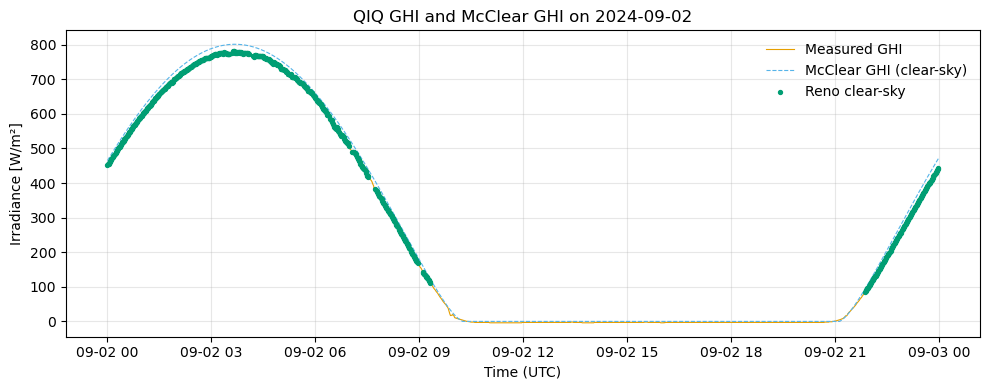

In [9]:
import matplotlib.pyplot as plt

# Choose a specific day in September
# 选择 9 月中的特定日期
sep2_str = "2024-09-02"
if sep2_str not in df_csd.index.strftime("%Y-%m-%d").unique():
    raise ValueError(f"No data found for {sep2_str} in df_csd.")

sep2 = df_csd.loc[sep2_str]

plt.figure(figsize=(10, 4))
plt.plot(sep2.index, sep2["ghi"], label="Measured GHI", color="#E69F00", linewidth=0.8)
plt.plot(sep2.index, sep2["ghi_clear"], label="McClear GHI (clear-sky)", color="#56B4E9", linestyle="--", linewidth=0.8)

# Highlight Reno clear-sky points
# 高亮 Reno 判定的晴空点
if "is_clearsky_reno" in sep2.columns:
    cs_mask = sep2["is_clearsky_reno"] == True
    if cs_mask.any():
        plt.scatter(
            sep2.index[cs_mask],
            sep2["ghi"][cs_mask],
            s=8,
            color="#009E73",
            label="Reno clear-sky",
            zorder=5,
        )

plt.title(f"{stn} GHI and McClear GHI on {sep2_str}")
plt.ylabel("Irradiance [W/m²]")
plt.xlabel("Time (UTC)")
plt.legend(frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()